#### Name: Solutions

# PHYS 230 Lab Assignment 13

### Monday, March 9, 2026: Chapter 6, sections 3.5 - 3.8
- Nonlinear equations - Newton's Method 

In [18]:
# put all import statements here
import math
import numpy as np
import matplotlib.pyplot as plt
import time 

## Newton's Method - single variable (22 pts)

Solve the same problem from class used for binary search, but analyzed using Newton's Method instead. 
Find the roots of $$ f(x) = e^{x-\sqrt{x}}-x$$

To do this: 

1) Take the derivative by hand. You can use something like WolframAlpha to check your derivative. Write it in markdown. 

2) Write two functions - `f(x)` that returns the result of the function for a given $x$ value and `df(x)` one that returns the derivative. 

3) Make a plot of the function from $x=0$ to $x=5$. Use this to estimate the roots. 

4) Apply the functions to find both roots. 

*You must clearly comment your code and include a markdown cell explaining your process*

The derivative is: 

$$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $$

In [ ]:
# part 1
## see above 

In [19]:
# part 2
# define functions
# function itself 
def f(x):
    return np.exp(x-np.sqrt(x))-x

# derivative of the function     
def df(x): 
    return np.exp(x-np.sqrt(x))*(1-1/(2*np.sqrt(x)))-1


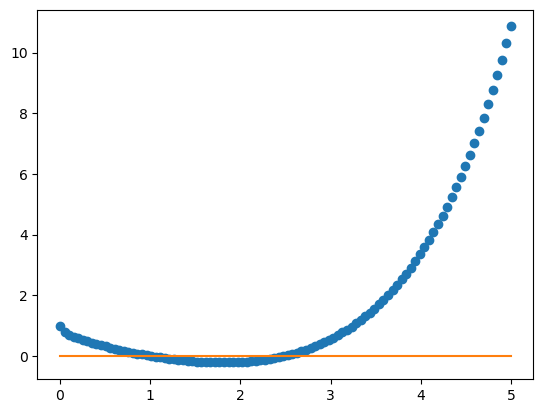

In [ ]:
# part 3
# make a plot to get initial guess
x = np.linspace(0,5,100)
y = f(x)
yline = np.zeros(100)
plt.plot(x,y, "o")
plt.plot(x,yline)
# could also use: 
# plt.axhline()


In [28]:
# part 4
# use plot to get initial guess
x_guess = [0.5, 2.5]
#x_guess = [1.5, 100.0] # funny enough can actually plug in 100 and it will still return the correct value quickly 
print("initial guesses =", x_guess[0], ",", x_guess[1])

# apply Newton's method
target = 1e-11  # accuracy 
# looping through both x values
for i in range(len(x_guess)):
    err = 1.0
    # keep looping for each value until reach desired accuracy 
    while err>target:
        delta = f(x_guess[i])/df(x_guess[i])
        x_guess[i] -= delta
        err = np.abs(delta) 
        

# print out results         
print("true values =", x_guess[0], ",", x_guess[1])

initial guesses = 0.5 , 2.5
true values = 1.0 , 2.4909093169459857


could alternatively use arrays and not doing a `for` loop

#### Don't forget to explain your process! 

## Newton's Method - many variables (22 pts)
#### Adapted from Nonlinear Circuits (book exercise 6.18, pg. 276)

Exercise 6.1 used regular simultaneous equations to solve for the behavior of circuits of resistors.  Resistors are linear---current is proportional to voltage---and the resulting equations we need to solve are therefore also linear and can be solved by standard matrix methods.  Real circuits, however, often include nonlinear components.  To solve for the behavior of these circuits we need to solve nonlinear equations.

Consider the following simple circuit, a variation on the classic
Wheatstone bridge:

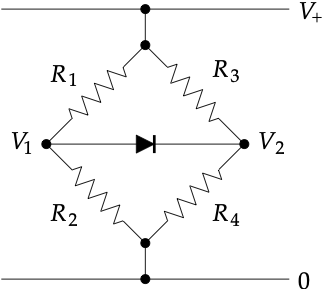

We will use Newton's Method to solve for the voltages in the 
The resistors obey the normal Ohm law, but the diode obeys the diode equation:
$$ I = I_0 (e^{V/V_T} - 1),$$
where $V$ is the voltage across the diode and $I_0$ and $V_T$ are constants.

The Kirchhoff current law says that the total net current flowing into or out of every point in a circuit must be zero.  Applying the law to voltage $V_1$ in the circuit above we get
$$
{V_1-V_+\over R_1} + {V_1\over R_2}
  + I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$$

   
1) In a markdown cell, derive the corresponding equation for voltage $V_2$.

2) Solve the two nonlinear equations for the voltages $V_1$ and $V_2$. 

3) Use Newton's method to solve the equations. This means you need to first take the derivatives of each equation with respect to each variable (so you'll have 4 equations). Define the Jacobian matrix. Setup the matrix necessary to analyze using the `np.linalg.solve()` function. Apply the following conditions: 

$$\begin{align*}
V_+ &= 5\,\textrm{V}, \\
R_1 &= 1\,\mathrm{k}\Omega, \qquad
R_2 = 4\,\mathrm{k}\Omega, \qquad
R_3 = 3\,\mathrm{k}\Omega, \qquad
R_4 = 2\,\mathrm{k}\Omega, \\
I_0 &= 3\,\textrm{nA},\qquad
V_T = 0.05\,\textrm{V}.
\end{align*}$$

4) Apply the function to find both roots to solve for $V_1$ and $V_2$. The electronic engineer's rule of thumb for diodes is that the voltage across a (forward biased) diode is always about 0.6 volts. Confirm that your results agree with this rule by taking the difference between your results.

*You must clearly comment your code and include a markdown cell explaining your process*

#### part 1

**Solution**
The corresponding equation for $V_2$ is: 

$$ \frac{V_2 - V_+}{R_3} + \frac{V_2}{R_4} - I_0\left[e^{(V_1-V_2)/V_T}-1\right] =0$$

$$\bf{J} =
\begin{pmatrix}
\frac{\partial}{\partial x} f(x,y) & \frac{\partial}{\partial y} f(x,y) \\
\frac{\partial}{\partial x} g(x,y) & \frac{\partial}{\partial y} g(x,y) \\
\end{pmatrix}$$

In our case, they are $f(V_1,V_2)$ and $g(V_1, V_2)$ making the derivatives wrt $V_1$ and $V_2$
$$
f(V_1,V_2)= {V_1-V_+\over R_1} + {V_1\over R_2}
  + I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$$

$$ g(V_1, V_2)= \frac{V_2 - V_+}{R_3} + \frac{V_2}{R_4} - I_0\left[e^{(V_1-V_2)/V_T}-1\right] =0$$

so the partial derivatives are: 

$$\frac{\partial}{\partial V_1}f(V_1,V_2) = \frac{1}{R_1}+\frac{1}{R_2}+\frac{I_0}{V_T}e^{(V_1-V_2)/V_T} $$
$$\frac{\partial}{\partial V_2}f(V_1,V_2) = -\frac{I_0}{V_T}e^{(V_1-V_2)/V_T}$$
$$\frac{\partial}{\partial V_1}g(V_1,V_2) = -\frac{I_0}{V_T}e^{(V_1-V_2)/V_T} $$
$$\frac{\partial}{\partial V_2}g(V_1,V_2) = \frac{1}{R_3}+\frac{1}{R_4}+\frac{I_0}{V_T}e^{(V_1-V_2)/V_T} $$

In [ ]:
# part 2 - said not to do this by hand so combining with part 3

In [13]:
# part 3
start = time.time()

# define variables 
Vp = 5.0 # volts
R1 = 1000.0 #ohms 
R2 = 4000.0 #ohms
R3 = 3000.0
R4 = 2000.0
I0 = 3.0e-9
VT = 0.05

# define a target accuracy 
target = 1.0e-9

# make initial guesses 
V1 = 2.0
V2 = 1.5

# def functions 
def f(V1,V2): 
    return (V1-Vp)/R1 + (V1)/R2 + I0*(np.exp((V1-V2)/VT)-1)
def g(V1,V2): 
    return (V2-Vp)/R3 + (V2)/R4 - I0*(np.exp((V1-V2)/VT)-1)

# define starting error value 
err = 1.0

# newton's method for multi-variable 
while err > target: 
    term = I0/VT*np.exp((V1-V2)/VT)
    a = 1/R1 + 1/R2 + term 
    b = -term 
    c = -term 
    d = 1/R3 + 1/R4 + term 
    A = np.array([[ a, b], 
                  [ c, d]], float)
    v = np.array([f(V1,V2),g(V1,V2)], float)  # functions evaluated at x value             
    xvals = np.linalg.solve(A,v)
    
    # calculate final results              
    V1 -= xvals[0]
    V2 -= xvals[1]
                 
    # calculate new error 
    err = np.sqrt(xvals[0]**2 +xvals[1]**2)

end = time.time()


In [ ]:
# part 4
print("The solutions are:", V1, "V and", V2, "V")
print("whole code took", end-start, "seconds")

# check to see if follows rule of thumb 
print("the difference between the results is", np.abs(V1-V2), "which is close to 0.6 V")


The solutions are: 3.4469546188585745 V and 2.8295680717121385 V
whole code took 0.001644134521484375 seconds
the difference between the results is 0.6173865471464359 which is close to 0.6 V


#### Don't forget to explain your process! 